# PX4 QUAD-SITL — `vehicle_local_position`

Posição **estimada** no frame **NED local** (fusão EKF), com velocidades e incertezas. Complementa `vehicle_gps_position`: útil para comparar **Normal** vs **GPS Spoofing** vs **Ping DoS**.


## Colunas mais úteis (resumo)

| Grupo | Colunas | Notas |
|-------|---------|--------|
| Tempo | `timestamp` | μs desde o início do log |
| Posição | `x`, `y`, `z` | NED local em **metros** (típico) |
| Velocidade | `vx`, `vy`, `vz` | m/s |
| Incerteza | `eph`, `epv`, `evh`, `evv` | Incertezas estimadas (ver unidades no export) |
| Atitude | `yaw` | rad |
| Referência | `ref_lat`, `ref_lon`, `ref_alt` | Referência global |


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def find_px4_quad_sitl() -> Path:
    'Sobe a partir do cwd até achar PX4-QUAD-SITL (raiz do repo ou notebooks/).'
    here = Path.cwd().resolve()
    for anchor in [here, *here.parents]:
        p = anchor / "data" / "UAVAttackData" / "Simulated - OTU Survey" / "PX4-QUAD-SITL"
        if p.is_dir():
            return p
    raise FileNotFoundError(
        "Não encontrei data/UAVAttackData/.../PX4-QUAD-SITL. "
        "Abra o kernel na raiz do projeto TCC ou em notebooks/."
    )


BASE_PATH = find_px4_quad_sitl()
NORMAL = BASE_PATH / "Normal"
SPOOFING = BASE_PATH / "GPS Spoofing"
DOS = BASE_PATH / "Ping DoS"

print("BASE_PATH:", BASE_PATH)


def pick_vehicle_local_position_csv(folder: Path) -> Path:
    matches = sorted(folder.glob("*vehicle_local_position*.csv"))
    matches = [m for m in matches if "setpoint" not in m.name and "groundtruth" not in m.name]
    if not matches:
        raise FileNotFoundError(f"Sem vehicle_local_position em: {folder}")
    if len(matches) > 1:
        print("Aviso: vários candidatos; usando:", matches[0].name)
    return matches[0]


BASE_PATH: /Users/caiolima/Documents/TCC/data/UAVAttackData/Simulated - OTU Survey/PX4-QUAD-SITL


## 1. Carregamento (três condições)

Coluna **`condition`** = pasta experimental.


In [2]:
paths = {
    "Normal": pick_vehicle_local_position_csv(NORMAL),
    "GPS Spoofing": pick_vehicle_local_position_csv(SPOOFING),
    "Ping DoS": pick_vehicle_local_position_csv(DOS),
}
for label, p in paths.items():
    print(f"{label}: {p.name}")

dfs = {label: pd.read_csv(p, sep=",") for label, p in paths.items()}
parts = [df.assign(condition=name) for name, df in dfs.items()]
df_all = pd.concat(parts, ignore_index=True)

display(df_all.groupby("condition").size().rename("n_linhas").to_frame())
df_all.head(2)


Normal: log_6_2020-8-1-21-26-31_vehicle_local_position_0.csv
GPS Spoofing: log_0_2020-8-2-10-39-13_vehicle_local_position_0.csv
Ping DoS: 001-2021-01-27-12-34-48-014_vehicle_local_position_0.csv


,n_linhas
condition,
GPS Spoofing,15453
Normal,14765
Ping DoS,14739


,timestamp,ref_timestamp,ref_lat,ref_lon,x,y,z,delta_xy[0],delta_xy[1],delta_z,...,v_xy_valid,v_z_valid,xy_reset_counter,z_reset_counter,vxy_reset_counter,vz_reset_counter,xy_global,z_global,dist_bottom_valid,condition
0,14148000,900000,43.945164,-78.896838,0.005196,0.000961,0.043389,-0.020427,-0.00391,0.0,...,1,1,2,0,2,2,1,1,1,Normal
1,14244000,900000,43.945164,-78.896838,0.006151,0.000024,0.044340,-0.020427,-0.00391,0.0,...,1,1,2,0,2,2,1,1,1,Normal


## 2. Tempo relativo, cadência e cinemática

- `t_rel_s`: segundos desde o primeiro timestamp do ficheiro
- `dt_s`: intervalo entre linhas
- `v_xy_m_s`: velocidade horizontal
- `r_xy_m`: raio horizontal ao primeiro ponto da série


In [3]:
def enrich_local(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    ts = out["timestamp"].astype("int64")
    out["t_rel_s"] = (ts - ts.min()) / 1e6
    out["dt_s"] = ts.diff() / 1e6
    out["v_xy_m_s"] = np.sqrt(out["vx"].astype(float) ** 2 + out["vy"].astype(float) ** 2)
    x0, y0 = float(out["x"].iloc[0]), float(out["y"].iloc[0])
    out["r_xy_m"] = np.sqrt((out["x"] - x0) ** 2 + (out["y"] - y0) ** 2)
    return out


dfs_e = {k: enrich_local(v) for k, v in dfs.items()}
df_all_e = pd.concat(
    [enrich_local(d.assign(condition=name)) for name, d in dfs.items()],
    ignore_index=True,
)

for name, d in dfs_e.items():
    print(name, "| n =", len(d), "| duração ~", float(d["t_rel_s"].max()), "s")


Normal | n = 14765 | duração ~ 1477.548 s
GPS Spoofing | n = 15453 | duração ~ 1546.38 s
Ping DoS | n = 14739 | duração ~ 1474.956 s


## 3. Cadência temporal (`dt`)

Histogramas + estatísticas de `dt_s`.

**Leitura dos resultados:** nos três ficheiros, `mean(dt)` ≈ **0,10 s** e a distribuição é praticamente a mesma. Isso reflete sobretudo a **taxa de publicação do tópico / do logger** no SITL, **não** o ataque em si. **Não** interprete ausência de diferença em `dt` como “o Ping DoS não afetou o sistema” — para enlace, outros tópicos ou fusão GPS↔local são mais informativos.


,count,mean,std,min,50%,90%,99%,max
condition,,,,,,,,
GPS Spoofing,15452.0,0.100076,0.004020,0.092000,0.103999,0.104,0.104,0.112001
Normal,14764.0,0.100078,0.004022,0.092000,0.103999,0.104,0.104,0.112001
Ping DoS,14738.0,0.100078,0.004020,0.095999,0.103999,0.104,0.104,0.112001


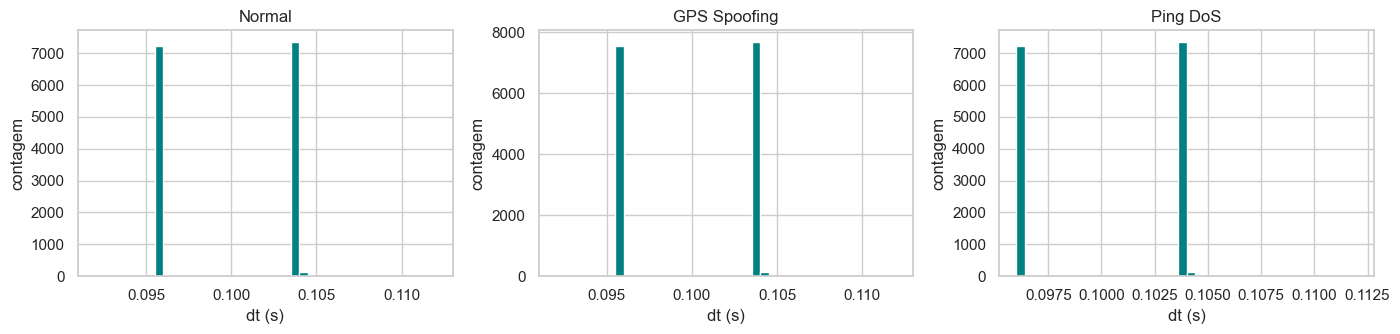

In [4]:
dt_stats = (
    df_all_e.dropna(subset=["dt_s"])
    .groupby("condition")["dt_s"]
    .describe(percentiles=[0.5, 0.9, 0.99])
    .round(6)
)
display(dt_stats)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    s = dfs_e[cond]["dt_s"].dropna()
    ax.hist(s, bins=40, color="teal", edgecolor="white")
    ax.set_title(cond)
    ax.set_xlabel("dt (s)")
    ax.set_ylabel("contagem")
plt.tight_layout()
plt.show()


## 4. Posição `x`, `y`, `z` (m)

Séries temporais por condição.


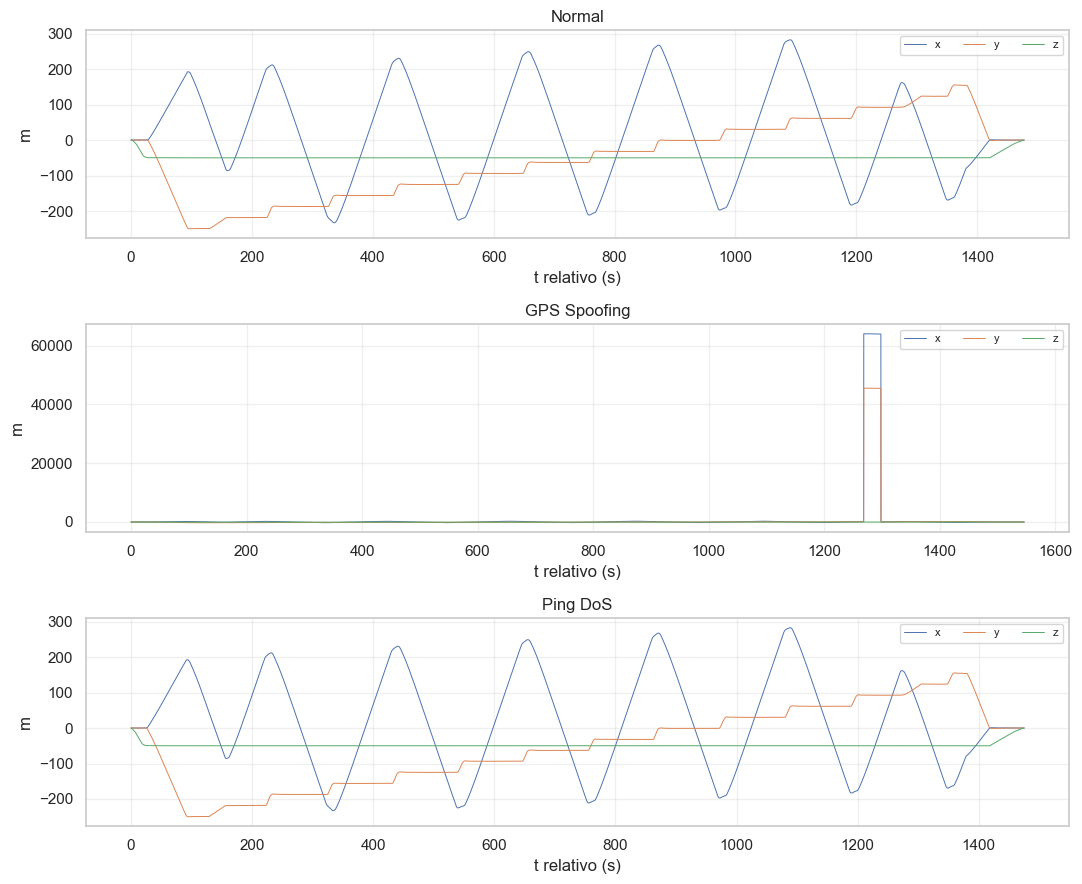

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = dfs_e[cond]
    ax.plot(d["t_rel_s"], d["x"], lw=0.7, label="x")
    ax.plot(d["t_rel_s"], d["y"], lw=0.7, label="y")
    ax.plot(d["t_rel_s"], d["z"], lw=0.7, label="z")
    ax.set_title(cond)
    ax.set_ylabel("m")
    ax.set_xlabel("t relativo (s)")
    ax.legend(loc="upper right", ncol=3, fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4b. Distância horizontal ao primeiro ponto (`r_xy_m`)

`r_xy_m` é a norma de \((x-x_0, y-y_0)\) com \((x_0,y_0)\) no **primeiro** registo do ficheiro. Útil para ver **deriva horizontal** sem misturar escalas de `x` e `y` no tempo.


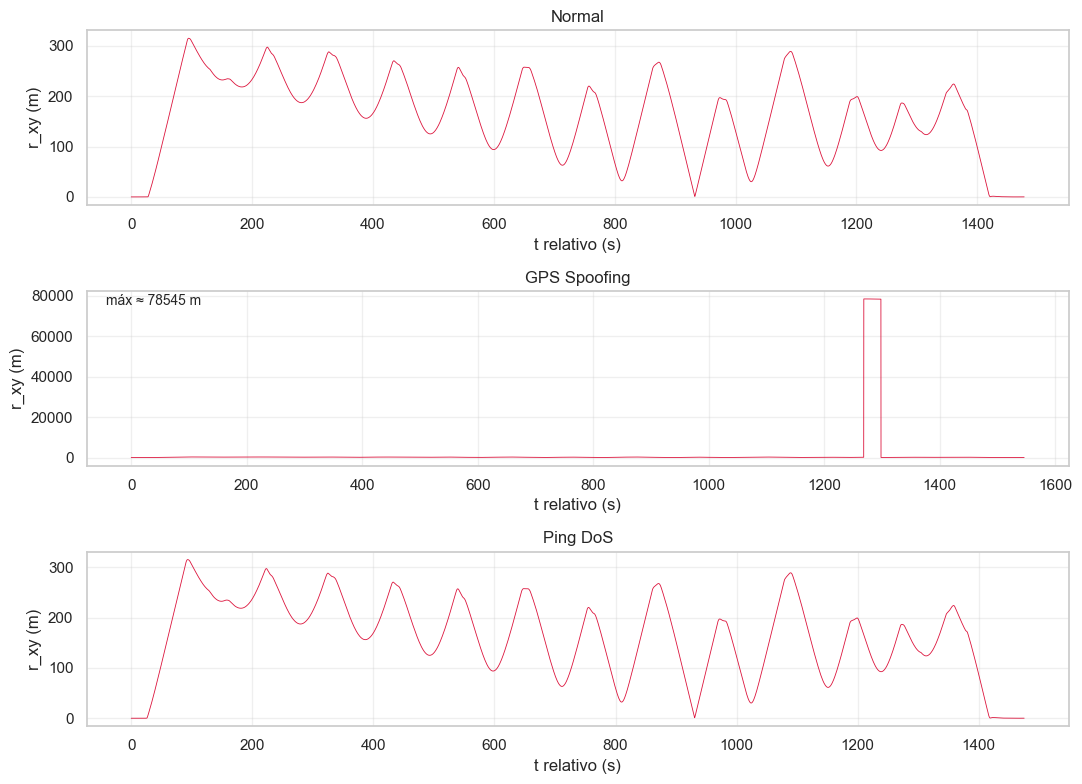

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = dfs_e[cond]
    ax.plot(d["t_rel_s"], d["r_xy_m"], lw=0.6, color="crimson")
    ax.set_title(cond)
    ax.set_ylabel("r_xy (m)")
    ax.set_xlabel("t relativo (s)")
    ax.grid(True, alpha=0.3)
    if cond == "GPS Spoofing":
        ax.annotate(
            f"máx ≈ {d['r_xy_m'].max():.0f} m",
            xy=(0.02, 0.92),
            xycoords="axes fraction",
            fontsize=10,
        )
plt.tight_layout()
plt.show()


## 5. Velocidade horizontal e `vz`

Twin axis por condição.


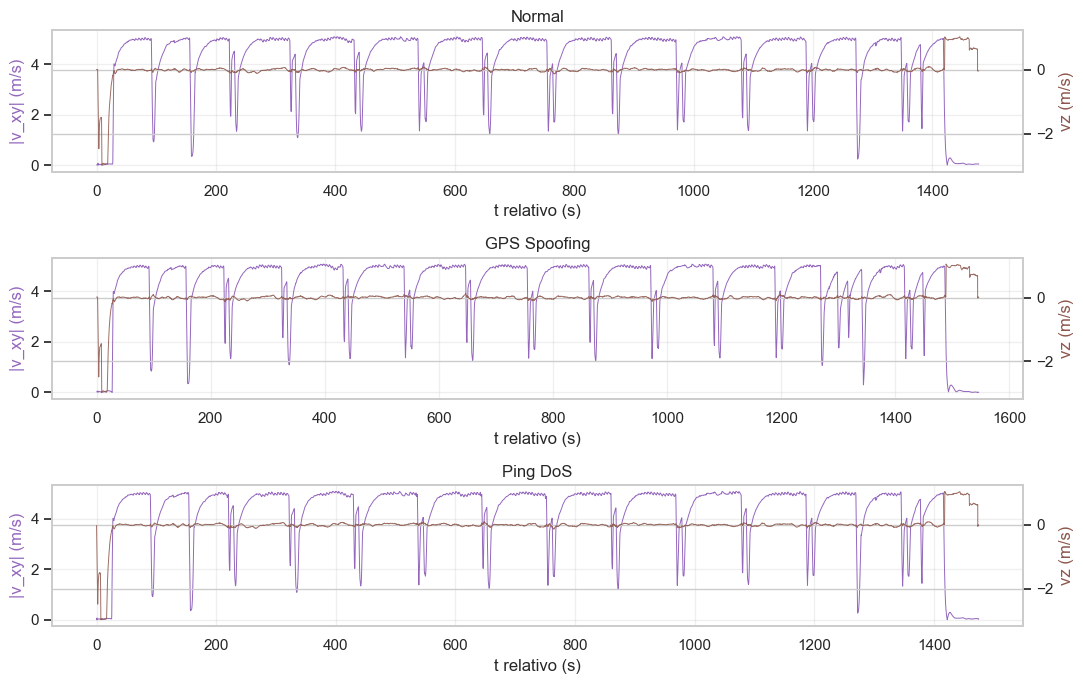

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = dfs_e[cond]
    ax.plot(d["t_rel_s"], d["v_xy_m_s"], lw=0.7, color="tab:purple", label="|v_xy|")
    ax2 = ax.twinx()
    ax2.plot(d["t_rel_s"], d["vz"], lw=0.7, color="tab:brown", alpha=0.85, label="vz")
    ax.set_ylabel("|v_xy| (m/s)", color="tab:purple")
    ax2.set_ylabel("vz (m/s)", color="tab:brown")
    ax.set_title(cond)
    ax.set_xlabel("t relativo (s)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Incertezas (`eph`, `epv`, `evh`, `evv`)

Boxplots por condição.

**Unidades (PX4 / mensagem local):** `eph` e `epv` são incertezas de **posição** (m); `evh` e `evv` são incertezas de **velocidade** (m/s) — não comparar numericamente entre si.

**Leitura dos resultados:** nas medianas deste export, **Normal**, **GPS Spoofing** e **Ping DoS** ficam **muito próximos** nesses quatro campos. Ou seja: os boxplots são válidos como **EDA**, mas **não** são o melhor discriminador aqui. O cenário de **spoofing** aparece com força na **trajetória** (`x`, `y`, §4 e §7) e na distância **`r_xy_m`** (§4b), onde a solução horizontal **deriva** muito mais que no Normal ou no Ping DoS.


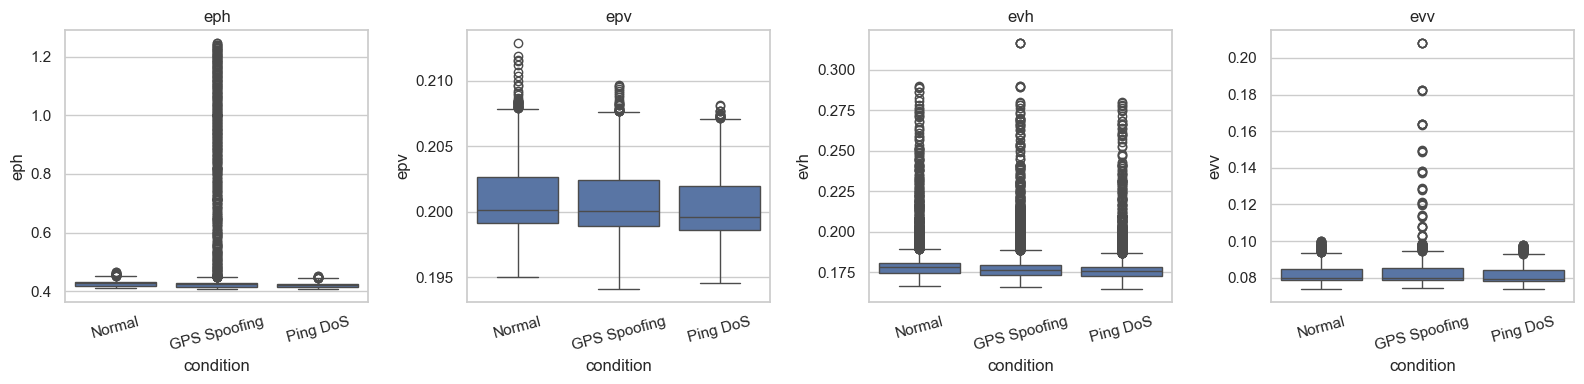

In [8]:
cols = [c for c in ["eph", "epv", "evh", "evv"] if c in df_all_e.columns]
if not cols:
    print("Sem colunas eph/epv/evh/evv neste export.")
else:
    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 4))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        sns.boxplot(data=df_all_e, x="condition", y=col, ax=ax)
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()


## 7. Trajetória no plano (`x` vs `y`)

Cor = tempo relativo.


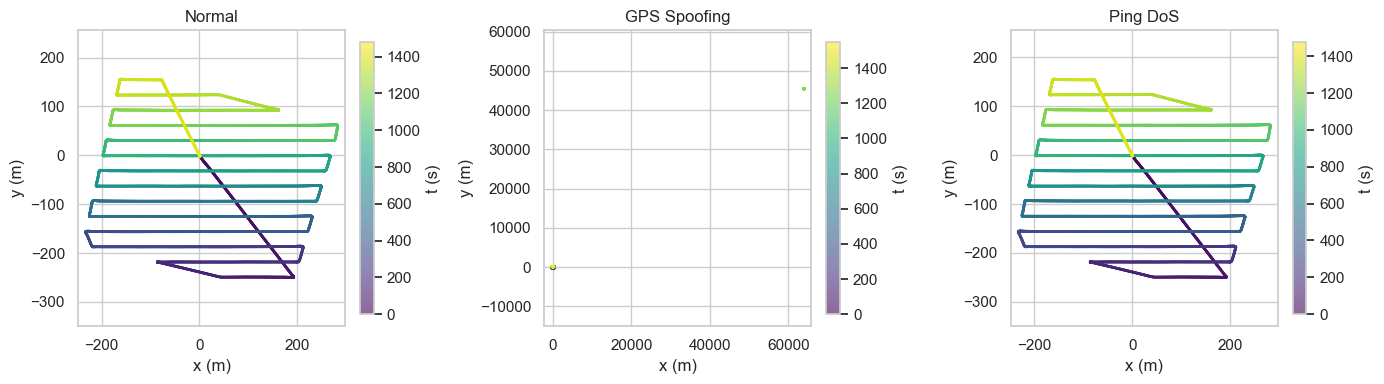

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=False, sharey=False)
for ax, cond in zip(axes, ["Normal", "GPS Spoofing", "Ping DoS"]):
    d = dfs_e[cond]
    sc = ax.scatter(d["x"], d["y"], c=d["t_rel_s"], s=1, cmap="viridis", alpha=0.6)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(cond)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    plt.colorbar(sc, ax=ax, label="t (s)", fraction=0.046)
plt.tight_layout()
plt.show()


## 8. Próximos passos

- `merge_asof` entre **`vehicle_gps_position`** e este tópico em `timestamp`.
- `estimator_innovations_*` para EKF sob ataque.
- LSTM em janelas; split **por ficheiro** (voo).
